# TUGAS BESAR DKA - FUZZY LOGIC
### Analisis Komparatif Logika Fuzzy Metode Mamdani dan Sugeno dengan Pendekatan Hybrid Machine Learning untuk Evaluasi Efisiensi Energi Rumah Pintar

---

**Anggota Kelompok:**

| Nama | NIM |
| :--- | :--- |
| Farrel Malik Pirade | 103012400068 |
| Ghifari Nurwafi Yoga | 103012400020 |
| Sava Arsya Syandana | 103012400043 |

<br>

**Dataset:** [Appliances Energy Prediction (UCI Machine Learning Repository)](https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction)

In [7]:
# SETUP & PERSIAPAN DATASET
# -------------------------

# Import Library
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from tqdm import tqdm
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Mount Google Drive untuk akses file dataset
drive.mount('/content/drive')

# Membaca dataset dari Drive
df = pd.read_csv('/content/drive/MyDrive/DKA/energydata_complete.csv')

# Memilih 6 variabel input (sensor) dan 1 output (Appliances/Energi)
cols = ['T_out', 'RH_out', 'Windspeed', 'T1', 'RH_1', 'T2', 'Appliances']
df_selected = df[cols].copy() # Menggunakan .copy() untuk menghindari SettingWithCopyWarning

# Menampilkan statistik
print("Statistik Deskriptif Variabel Input & Output:")
display(df_selected.describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Statistik Deskriptif Variabel Input & Output:


,T_out,RH_out,Windspeed,T1,RH_1,T2,Appliances
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,7.411665,79.750418,4.039752,21.686571,40.259739,20.341219,97.694958
std,5.317409,14.901088,2.451221,1.606066,3.979299,2.192974,102.524891
min,-5.000000,24.000000,0.000000,16.790000,27.023333,16.100000,10.000000
25%,3.666667,70.333333,2.000000,20.760000,37.333333,18.790000,50.000000
50%,6.916667,83.666667,3.666667,21.600000,39.656667,20.000000,60.000000
75%,10.408333,91.666667,5.500000,22.600000,43.066667,21.500000,100.000000
max,26.100000,100.000000,14.000000,26.260000,63.360000,29.856667,1080.000000


## Eksplorasi Data (Matriks Korelasi)
Sebelum merancang *Rule Base* Fuzzy, kami melakukan pengecekan korelasi antar variabel menggunakan Heatmap. Hal ini bertujuan untuk memvalidasi bahwa 6 variabel input (suhu dan kelembapan) yang dipilih benar-benar memiliki hubungan statistik dengan target *Appliances* (penggunaan energi).

<br>

### Pearson Correlation
Seleksi 6 variabel input lingkungan (*Temperature* dan *Humidity*) tidak dilakukan secara acak, melainkan divalidasi menggunakan matriks korelasi **Pearson**. Rumus yang digunakan untuk mencari kedekatan hubungan linier antar variabel sensor dengan target (*Appliances*) adalah:

$$r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}}$$

Nilai $r$ yang mendekati 1 atau -1 menunjukkan korelasi yang kuat, sehingga variabel tersebut dipertahankan sebagai input bagi sistem Fuzzy.


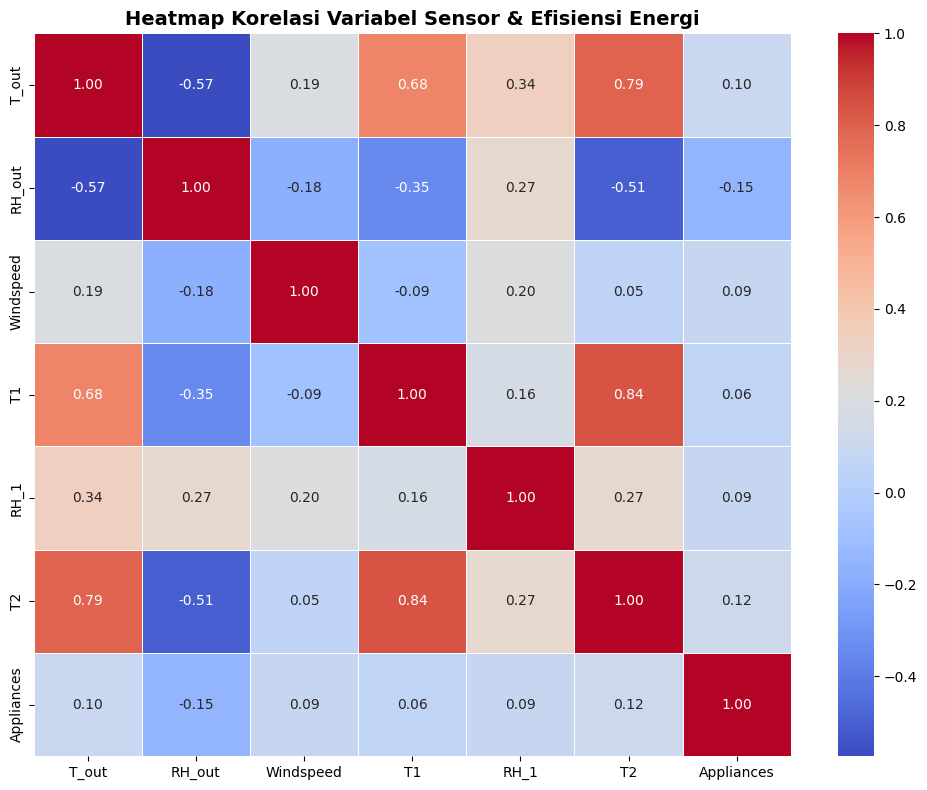

In [8]:
# VISUALISASI MATRIKS KORELASI (Eksplorasi Data)
# ----------------------------------------------
import seaborn as sns

plt.figure(figsize=(10, 8))
# Membuat heatmap korelasi menggunakan Pearson method
korelasi = df_selected.corr()

# Anotasi heatmap
sns.heatmap(korelasi, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Heatmap Korelasi Variabel Sensor & Efisiensi Energi", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## TAHAP 1: Fuzzifikasi (Pembuatan Fungsi Keanggotaan)
Pada tahap ini, sistem mengubah nilai *crisp* (angka pasti dari sensor) menjadi nilai *fuzzy* (derajat keanggotaan 0 hingga 1). Kami membangun tiga fungsi keanggotaan utama secara *from scratch* :
* **Left Shoulder:** Untuk kategori nilai rendah/dingin.
* **Triangle (Segitiga):** Untuk kategori nilai sedang/normal.
* **Right Shoulder:** Untuk kategori nilai tinggi/panas.

> **Catatan Pendekatan:** Batas parameter (titik a, b, c) pada setiap fungsi keanggotaan tidak dibentuk menggunakan *clustering* otomatis, melainkan ditentukan secara manual melalui pendekatan **Expert Knowledge** yang didukung oleh analisis kuartil dari statistik deskriptif dataset.

### Formulasi Fungsi Keanggotaan (Membership Functions)
Karena sistem Fuzzy dibangun murni *from scratch*, berikut adalah landasan matematis untuk tiga kurva keanggotaan utama yang kami formulasikan di dalam kode:

**1. Kurva Bahu Kiri (Left Shoulder)**
Digunakan untuk mendeteksi intensitas nilai rendah/dingin. Titik $a$ adalah batas atas kebenaran mutlak (1), dan $b$ adalah titik turun ke 0.
$$f(x) = \begin{cases} 1 & x \leq a \\ \frac{b - x}{b - a} & a < x < b \\ 0 & x \geq b \end{cases}$$

**2. Kurva Segitiga (Triangle)**
Digunakan untuk menangkap nilai ekuilibrium (normal/nyaman). Titik $b$ adalah puncak kebenaran (1), diapit oleh titik $a$ dan $c$.
$$f(x) = \begin{cases} 0 & x \leq a \text{ atau } x \geq c \\ \frac{x - a}{b - a} & a < x \leq b \\ \frac{c - x}{c - b} & b < x < c \end{cases}$$

**3. Kurva Bahu Kanan (Right Shoulder)**
Digunakan untuk mendeteksi intensitas nilai tinggi/panas. Titik $a$ adalah awal kenaikan dari 0, dan $b$ adalah batas awal kebenaran mutlak (1).
$$f(x) = \begin{cases} 0 & x \leq a \\ \frac{x - a}{b - a} & a < x < b \\ 1 & x \geq b \end{cases}$$

In [9]:
# TAHAP 1: FUNGSI DASAR & FUZZIFIKASI 6 VARIABEL INPUT
# ----------------------------------------------------

# Fungsi Dasar
# ------------
def left_shoulder(x, a, b):
    """Fungsi untuk kurva bahu kiri (menurun dari 1 ke 0)"""
    if x <= a:
      return 1.0
    elif a < x < b:
      return (b - x) / (b - a)
    else:
      return 0.0

def triangle(x, a, b, c):
    """Fungsi untuk kurva segitiga (naik ke puncak b, turun ke c)"""
    if x <= a or x >= c:
      return 0.0
    elif a < x <= b:
      return (x - a) / (b - a)
    elif b < x < c:
      return (c - x) / (c - b)
    else:
      return 0.0

def right_shoulder(x, a, b):
    """Fungsi untuk kurva bahu kanan (naik dari 0 ke 1)"""
    if x <= a:
      return 0.0
    elif a < x < b:
      return (x - a) / (b - a)
    else:
      return 1.0

# NOTE: Threshold (batas nilai) di bawah ini adalah hasil penetapan manual (Expert/Domain Knowledge)
# berdasarkan nilai min, max, dan persentil dari data statistik.

# Fuzzifikasi Faktor Eksternal
# ----------------------------
def fuzzify_T_out(x):
    # Suhu Luar: Dingin, Sejuk, Panas
    return {
        "Dingin": left_shoulder(x, 3.6, 6.9),
        "Sejuk": triangle(x, 3.6, 6.9, 10.4),
        "Panas": right_shoulder(x, 6.9, 10.4)
    }

def fuzzify_RH_out(x):
    # Kelembapan Luar: Kering, Normal, Lembap
    return {
        "Kering": left_shoulder(x, 50, 70),
        "Normal": triangle(x, 60, 77, 85),
        "Lembap": right_shoulder(x, 80, 90)
    }

def fuzzify_Windspeed(x):
    # Kecepatan Angin: Tenang, Sedang, Kencang
    return {
        "Tenang": left_shoulder(x, 1.5, 2.5),
        "Sedang": triangle(x, 1.5, 3.6, 6.0),
        "Kencang": right_shoulder(x, 5.0, 8.0)
    }

# Fuzzifikasi Faktor Internal
# ---------------------------
def fuzzify_T1(x):
    # Suhu Dapur: Rendah, Normal, Tinggi
    return {
        "Rendah": left_shoulder(x, 18.5, 19.5),
        "Normal": triangle(x, 18.5, 21.6, 22.5),
        "Tinggi": right_shoulder(x, 22.0, 23.0)
    }

def fuzzify_RH_1(x):
    # Kelembapan Dapur: Rendah, Normal, Tinggi
    return {
        "Rendah": left_shoulder(x, 32.0, 35.0),
        "Normal": triangle(x, 32.0, 39.6, 45.0),
        "Tinggi": right_shoulder(x, 42.0, 45.0)
    }

def fuzzify_T2(x):
    # Suhu Ruang Keluarga: Dingin, Nyaman, Panas
    return {
        "Dingin": left_shoulder(x, 17.5, 18.5),
        "Nyaman": triangle(x, 17.5, 20.0, 22.5),
        "Panas": right_shoulder(x, 22.0, 23.0)
    }

### Visualisasi Fungsi Keanggotaan
Grafik di bawah ini memvisualisasikan batas parameter fungsi keanggotaan (*Left Shoulder, Triangle, Right Shoulder*) yang telah didefinisikan sebelumnya. Titik perpotongan antar kurva menunjukkan area abu-abu (*fuzziness*) di mana suatu nilai suhu memiliki derajat keanggotaan pada lebih dari satu himpunan linguistik secara bersamaan.

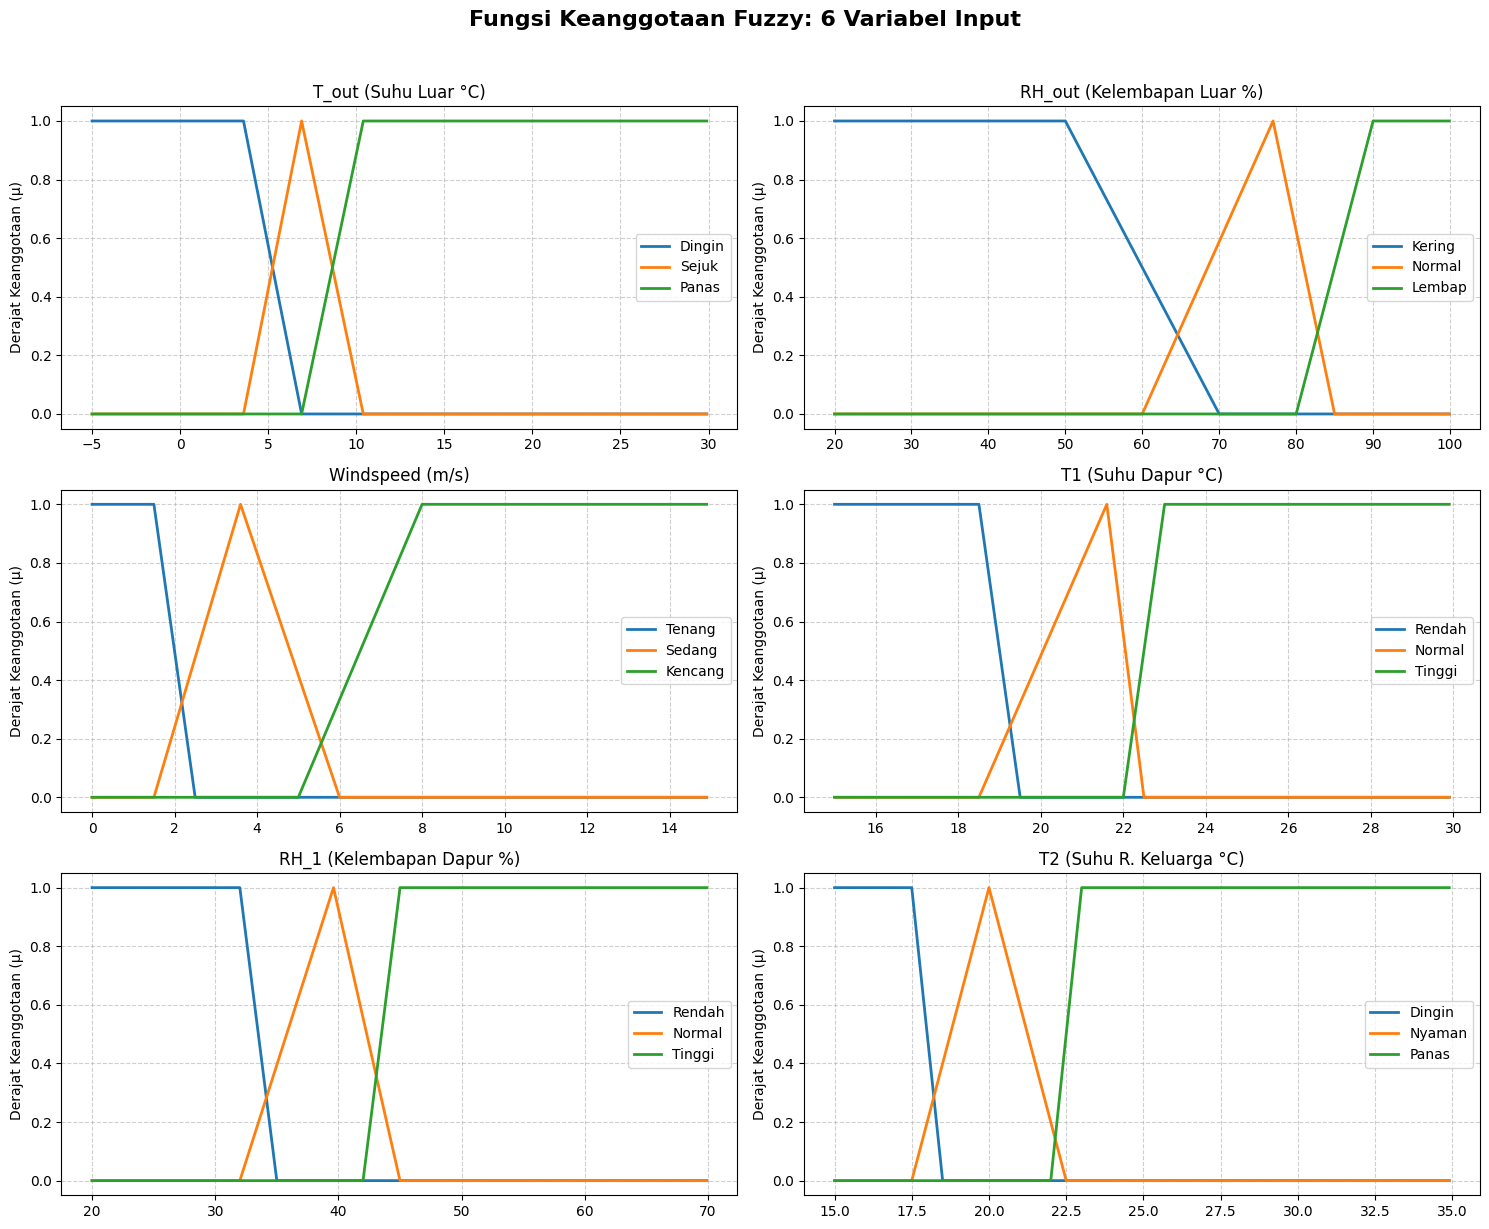

In [10]:
# VISUALISASI SELURUH FUNGSI KEANGGOTAAN INPUT (Grid 3x2)
# -------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle("Fungsi Keanggotaan Fuzzy: 6 Variabel Input", fontsize=16, fontweight='bold', y=1.02)

# 1. T_out (Suhu Luar)
x = np.arange(-5, 30, 0.1)
axes[0, 0].plot(x, [left_shoulder(i, 3.6, 6.9) for i in x], label="Dingin", lw=2)
axes[0, 0].plot(x, [triangle(i, 3.6, 6.9, 10.4) for i in x], label="Sejuk", lw=2)
axes[0, 0].plot(x, [right_shoulder(i, 6.9, 10.4) for i in x], label="Panas", lw=2)
axes[0, 0].set_title("T_out (Suhu Luar °C)")
axes[0, 0].legend()

# 2. RH_out (Lembap Luar)
x = np.arange(20, 100, 0.1)
axes[0, 1].plot(x, [left_shoulder(i, 50, 70) for i in x], label="Kering", lw=2)
axes[0, 1].plot(x, [triangle(i, 60, 77, 85) for i in x], label="Normal", lw=2)
axes[0, 1].plot(x, [right_shoulder(i, 80, 90) for i in x], label="Lembap", lw=2)
axes[0, 1].set_title("RH_out (Kelembapan Luar %)")
axes[0, 1].legend()

# 3. Windspeed (Kecepatan Angin)
x = np.arange(0, 15, 0.1)
axes[1, 0].plot(x, [left_shoulder(i, 1.5, 2.5) for i in x], label="Tenang", lw=2)
axes[1, 0].plot(x, [triangle(i, 1.5, 3.6, 6.0) for i in x], label="Sedang", lw=2)
axes[1, 0].plot(x, [right_shoulder(i, 5.0, 8.0) for i in x], label="Kencang", lw=2)
axes[1, 0].set_title("Windspeed (m/s)")
axes[1, 0].legend()

# 4. T1 (Suhu Dapur)
x = np.arange(15, 30, 0.1)
axes[1, 1].plot(x, [left_shoulder(i, 18.5, 19.5) for i in x], label="Rendah", lw=2)
axes[1, 1].plot(x, [triangle(i, 18.5, 21.6, 22.5) for i in x], label="Normal", lw=2)
axes[1, 1].plot(x, [right_shoulder(i, 22.0, 23.0) for i in x], label="Tinggi", lw=2)
axes[1, 1].set_title("T1 (Suhu Dapur °C)")
axes[1, 1].legend()

# 5. RH_1 (Lembap Dapur)
x = np.arange(20, 70, 0.1)
axes[2, 0].plot(x, [left_shoulder(i, 32.0, 35.0) for i in x], label="Rendah", lw=2)
axes[2, 0].plot(x, [triangle(i, 32.0, 39.6, 45.0) for i in x], label="Normal", lw=2)
axes[2, 0].plot(x, [right_shoulder(i, 42.0, 45.0) for i in x], label="Tinggi", lw=2)
axes[2, 0].set_title("RH_1 (Kelembapan Dapur %)")
axes[2, 0].legend()

# 6. T2 (Suhu Ruang Keluarga)
x = np.arange(15, 35, 0.1)
axes[2, 1].plot(x, [left_shoulder(i, 17.5, 18.5) for i in x], label="Dingin", lw=2)
axes[2, 1].plot(x, [triangle(i, 17.5, 20.0, 22.5) for i in x], label="Nyaman", lw=2)
axes[2, 1].plot(x, [right_shoulder(i, 22.0, 23.0) for i in x], label="Panas", lw=2)
axes[2, 1].set_title("T2 (Suhu R. Keluarga °C)")
axes[2, 1].legend()

for ax in axes.flat:
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_ylabel('Derajat Keanggotaan (μ)')

plt.tight_layout()
plt.show()

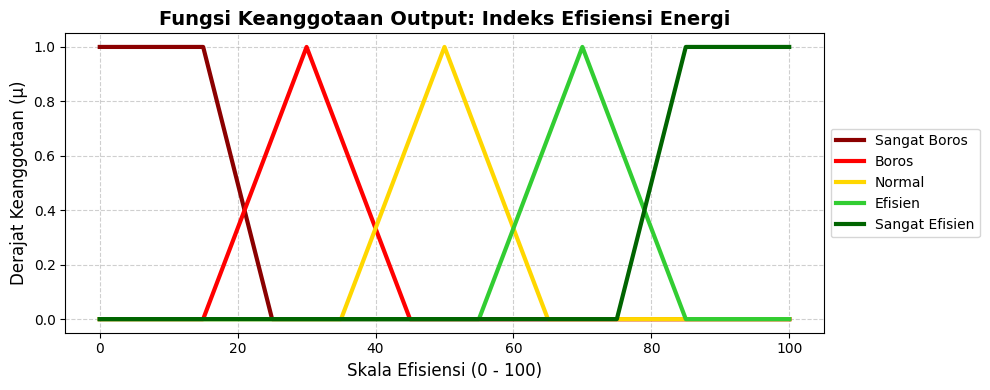

In [11]:
# VISUALISASI FUNGSI KEANGGOTAAN OUTPUT (Indeks Efisiensi Mamdani)
# ----------------------------------------------------------------

x_out = np.arange(0, 101, 1)

y_sangat_boros = [left_shoulder(x, 15, 25) for x in x_out]
y_boros        = [triangle(x, 15, 30, 45) for x in x_out]
y_normal       = [triangle(x, 35, 50, 65) for x in x_out]
y_efisien      = [triangle(x, 55, 70, 85) for x in x_out]
y_sangat_efisien = [right_shoulder(x, 75, 85) for x in x_out]

plt.figure(figsize=(10, 4))
plt.plot(x_out, y_sangat_boros, label="Sangat Boros", color='darkred', lw=3)
plt.plot(x_out, y_boros, label="Boros", color='red', lw=3)
plt.plot(x_out, y_normal, label="Normal", color='gold', lw=3)
plt.plot(x_out, y_efisien, label="Efisien", color='limegreen', lw=3)
plt.plot(x_out, y_sangat_efisien, label="Sangat Efisien", color='darkgreen', lw=3)

plt.title("Fungsi Keanggotaan Output: Indeks Efisiensi Energi", fontsize=14, fontweight='bold')
plt.xlabel("Skala Efisiensi (0 - 100)", fontsize=12)
plt.ylabel("Derajat Keanggotaan (μ)", fontsize=12)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## TAHAP 2: Mesin Inferensi (Rule Base)
Kumpulan 25 aturan (Rule Base) dievaluasi menggunakan operator `AND` (fungsi MIN). Karena menggunakan pendekatan *Expert Knowledge*, aturan ini dirancang berdasarkan logika rasional manusia terhadap hubungan cuaca, suhu ruangan, dan efisiensi energi.

Hasil dari inferensi dikelompokkan menjadi 5 kategori output linguistik:
1. Sangat Boros (10)
2. Boros (30)
3. Normal (50)
4. Efisien (75)
5. Sangat Efisien (90)

Nilai akhir untuk tiap kategori diambil menggunakan operator agregasi `MAX`.

In [12]:
# TAHAP 2: MESIN INFERENSI & AGREGASI
# -----------------------------------

def evaluasi_rules_lengkap(f_T_out, f_RH_out, f_Wind, f_T1, f_RH_1, f_T2):
    # Dictionary penampung kekuatan untuk setiap kategori efisiensi
    out = {"Sangat_Boros": [], "Boros": [], "Normal": [], "Efisien": [], "Sangat_Efisien": []}

    # KATEGORI 1: Kondisi lingkungan yang menyebabkan pemborosan energi (R1 - R7)
    out["Sangat_Boros"].append(min(f_T_out["Dingin"], f_T2["Panas"]))
    out["Sangat_Boros"].append(min(f_T_out["Panas"], f_T2["Dingin"]))
    out["Sangat_Boros"].append(min(f_T_out["Panas"], f_Wind["Kencang"], f_T2["Dingin"]))
    out["Sangat_Boros"].append(min(f_T_out["Dingin"], f_Wind["Kencang"], f_T2["Panas"]))
    out["Sangat_Boros"].append(min(f_RH_out["Lembap"], f_T_out["Panas"], f_T2["Dingin"]))
    out["Boros"].append(min(f_T1["Rendah"], f_RH_1["Rendah"], f_T2["Panas"]))
    out["Boros"].append(min(f_T2["Panas"], f_T_out["Sejuk"]))

    # KATEGORI 2: Kondisi aktivitas dalam rumah (Dapur) yang efisien (R8 - R12)
    out["Efisien"].append(min(f_T1["Tinggi"], f_RH_1["Tinggi"]))
    out["Sangat_Efisien"].append(min(f_T1["Tinggi"], f_RH_1["Tinggi"], f_T_out["Dingin"]))
    out["Efisien"].append(min(f_T1["Normal"], f_RH_1["Tinggi"]))
    out["Efisien"].append(min(f_T1["Tinggi"], f_RH_1["Normal"]))
    out["Sangat_Efisien"].append(min(f_T1["Tinggi"], f_RH_1["Tinggi"], f_T2["Nyaman"]))

    # KATEGORI 3: Kondisi Normal/Netral (R13 - R19)
    out["Normal"].append(min(f_T_out["Sejuk"], f_T2["Nyaman"], f_T1["Normal"]))
    out["Normal"].append(min(f_Wind["Sedang"], f_T_out["Sejuk"]))
    out["Normal"].append(min(f_RH_out["Normal"], f_RH_1["Normal"]))
    out["Normal"].append(min(f_T1["Rendah"], f_T2["Dingin"], f_T_out["Dingin"]))
    out["Normal"].append(min(f_T1["Rendah"], f_RH_1["Rendah"], f_T2["Nyaman"]))
    out["Normal"].append(min(f_T_out["Panas"], f_T2["Nyaman"]))
    out["Normal"].append(min(f_RH_out["Kering"], f_RH_1["Rendah"]))

    # KATEGORI 4: Kondisi Harmoni / Sangat Efisien (R20 - R25)
    out["Sangat_Efisien"].append(min(f_T_out["Sejuk"], f_T2["Nyaman"], f_RH_out["Normal"]))
    out["Sangat_Efisien"].append(min(f_T_out["Sejuk"], f_T1["Normal"], f_Wind["Tenang"]))
    out["Sangat_Efisien"].append(min(f_T2["Nyaman"], f_T1["Normal"], f_RH_1["Normal"]))
    out["Sangat_Efisien"].append(min(f_T_out["Dingin"], f_T2["Dingin"]))
    out["Sangat_Efisien"].append(min(f_T_out["Panas"], f_T2["Panas"]))
    out["Sangat_Efisien"].append(min(f_Wind["Tenang"], f_RH_out["Normal"], f_T2["Nyaman"]))

    # AGREGASI MAX: Mengambil nilai rule terkuat (paling merepresentasikan) dari tiap kategori
    return {kategori: max(nilai) if nilai else 0.0 for kategori, nilai in out.items()}

## TAHAP 3 & 4: Defuzzifikasi (Mamdani vs Sugeno)
Tahap untuk mengembalikan nilai linguistik menjadi nilai *crisp* (0-100%).
* **Metode Sugeno:** Menggunakan rumus rata-rata terbobot *(Weighted Average)* dari nilai konstan singleton. Lebih cepat secara komputasi.
* **Metode Mamdani:** Menggunakan metode Titik Berat *(Centroid)* dengan menghitung luas area di bawah kurva output. Memerlukan integrasi/looping pada sumbu X.


In [13]:
# TAHAP 3: DEFUZZIFIKASI SUGENO (Weighted Average)
# ------------------------------------------------

def defuzzifikasi_sugeno(hasil_agregasi):
    # Nilai singleton konstan untuk metode Sugeno
    nilai_konstan = {
        "Sangat_Boros": 10.0, "Boros": 30.0, "Normal": 50.0,
        "Efisien": 75.0, "Sangat_Efisien": 90.0
    }

    # Rumus Weighted Average = Sigma(Bobot * Nilai) / Sigma(Bobot)
    pembilang = sum(alpha * nilai_konstan[kat] for kat, alpha in hasil_agregasi.items())
    penyebut = sum(hasil_agregasi.values())

    if penyebut == 0:
      return 0.0

    return round(pembilang / penyebut, 2)


# TAHAP 4: DEFUZZIFIKASI MAMDANI (Centroid / Titik Berat)
# -------------------------------------------------------

def defuzzifikasi_mamdani(hasil_agregasi):
    # Membuat diskritisasi sumbu X (Skala efisiensi 0 - 100)
    x_grid = np.arange(0, 101, 1)
    pembilang, penyebut = 0.0, 0.0

    for x in x_grid:
        # Menghitung derajat pada kurva output untuk titik x tertentu
        sb = left_shoulder(x, 15, 25)
        b  = triangle(x, 15, 30, 45)
        n  = triangle(x, 35, 50, 65)
        e  = triangle(x, 55, 70, 85)
        se = right_shoulder(x, 75, 85)

        # Memotong (clipping) kurva sesuai dengan hasil agregasi dari inferensi
        potong_sb = min(sb, hasil_agregasi["Sangat_Boros"])
        potong_b  = min(b, hasil_agregasi["Boros"])
        potong_n  = min(n, hasil_agregasi["Normal"])
        potong_e  = min(e, hasil_agregasi["Efisien"])
        potong_se = min(se, hasil_agregasi["Sangat_Efisien"])

        # Menggabungkan area yang sudah dipotong (Union / MAX)
        area_gabungan = max(potong_sb, potong_b, potong_n, potong_e, potong_se)

        # Menjumlahkan momen dan area untuk mencari titik berat (centroid)
        pembilang += x * area_gabungan
        penyebut += area_gabungan


    if penyebut == 0:
      return 0.0

    return round(pembilang / penyebut, 2)

## TAHAP 5: Evaluasi Komparatif Sistem Fuzzy (19.735 Baris)
Sistem memproses seluruh dataset (19.735 baris data) secara otomatis. Kami menyamakan skala kolom **Appliances (Wh)** menjadi persentase **Efisiensi Aktual (0-100%)** menggunakan *Inverse Min-Max Scaling* untuk membandingkan performa Mamdani dan Sugeno menggunakan metrik **Mean Absolute Error (MAE)**.

In [14]:
# TAHAP 5: PENGUJIAN SISTEM KESELURUHAN & EVALUASI MAE/MSE
# --------------------------------------------------------

# Mengaktifkan progress bar pada Pandas agar proses apply terlihat
tqdm.pandas(desc="Memproses Data Fuzzy")

def jalankan_fuzzy(row):
    """Fungsi pembantu untuk menjalankan proses fuzzy per baris data"""
    f_T_out = fuzzify_T_out(row['T_out'])
    f_RH_out = fuzzify_RH_out(row['RH_out'])
    f_Wind = fuzzify_Windspeed(row['Windspeed'])
    f_T1 = fuzzify_T1(row['T1'])
    f_RH_1 = fuzzify_RH_1(row['RH_1'])
    f_T2 = fuzzify_T2(row['T2'])

    hasil_agregasi = evaluasi_rules_lengkap(f_T_out, f_RH_out, f_Wind, f_T1, f_RH_1, f_T2)

    skor_sugeno = defuzzifikasi_sugeno(hasil_agregasi)
    skor_mamdani = defuzzifikasi_mamdani(hasil_agregasi)

    return pd.Series([skor_sugeno, skor_mamdani])

# --- Eksekusi Utama Tahap 5 ---
if __name__ == "__main__":
    # 1. Menghitung Prediksi Fuzzy untuk seluruh baris data (Takes ~15 seconds)
    df_selected[['Prediksi_Sugeno', 'Prediksi_Mamdani']] = df_selected.progress_apply(jalankan_fuzzy, axis=1)

    # 2. Konversi Ground Truth (Appliances) ke Skala Efisiensi (0-100)
    # Semakin kecil nilai konsumsi energi, semakin mendekati efisiensi 100%
    min_app = df_selected['Appliances'].min()
    max_app = df_selected['Appliances'].max()
    df_selected['Efisiensi_Aktual'] = 100 - (((df_selected['Appliances'] - min_app) / (max_app - min_app)) * 100)

    # 3. Menghitung Metrik Error Sugeno vs Mamdani
    mae_sugeno = mean_absolute_error(df_selected['Efisiensi_Aktual'], df_selected['Prediksi_Sugeno'])
    mse_sugeno = mean_squared_error(df_selected['Efisiensi_Aktual'], df_selected['Prediksi_Sugeno'])

    mae_mamdani = mean_absolute_error(df_selected['Efisiensi_Aktual'], df_selected['Prediksi_Mamdani'])
    mse_mamdani = mean_squared_error(df_selected['Efisiensi_Aktual'], df_selected['Prediksi_Mamdani'])

    print("\n" + "="*50)
    print("HASIL EVALUASI KOMPARATIF: MAMDANI VS SUGENO")
    print("="*50)
    print(f"1. SUGENO  -> MAE: {mae_sugeno:.2f} | MSE: {mse_sugeno:.2f}")
    print(f"2. MAMDANI -> MAE: {mae_mamdani:.2f} | MSE: {mse_mamdani:.2f}")

    print("\n--- Tampilan 5 Data Pertama ---")
    display(df_selected[['Appliances', 'Efisiensi_Aktual', 'Prediksi_Sugeno', 'Prediksi_Mamdani']].head())

Memproses Data Fuzzy: 100%|██████████| 19735/19735 [00:18<00:00, 1046.89it/s]


HASIL EVALUASI KOMPARATIF: MAMDANI VS SUGENO
1. SUGENO  -> MAE: 19.87 | MSE: 509.58
2. MAMDANI -> MAE: 20.87 | MSE: 552.44

--- Tampilan 5 Data Pertama ---


,Appliances,Efisiensi_Aktual,Prediksi_Sugeno,Prediksi_Mamdani
0,60,95.327103,62.5,60.0
1,60,95.327103,62.5,60.0
2,50,96.261682,62.5,60.0
3,50,96.261682,62.5,60.0
4,60,95.327103,62.5,60.0


In [15]:
# Menyimpan hasil ke file CSV
df_selected.to_csv('hasil_evaluasi_fuzzy.csv', index=False)

## TAHAP 6: Hybrid Machine Learning (Fitur Ekstraksi)
Tahapan ini mengimplementasikan skenario **Hybrid (Fuzzy + ML)** menggunakan algoritma *Random Forest Regressor*.

Sistem ML tidak menggantikan logika Fuzzy. Justru, karena Fuzzy pada tahap sebelumnya murni mengandalkan **Expert Knowledge (Manual)**, model ML di sini bertugas mengkoreksi bias manusia tersebut dengan menemukan pola **Data-Driven** yang lebih presisi. Kami menggunakan hasil `Prediksi_Sugeno` sebagai fitur tambahan (pengetahuan pakar) untuk memperkecil nilai error secara drastis.

In [16]:
# TAHAP 6: HYBRID MACHINE LEARNING (Pencapaian Bonus)
# ---------------------------------------------------

# 1. Definisikan Variabel Input dan Target Aktual
fitur_asli = ['T_out', 'RH_out', 'Windspeed', 'T1', 'RH_1', 'T2']
target = 'Efisiensi_Aktual'

# Membandingkan dua skenario input (Hanya fitur mentah VS Fitur Mentah + Hasil Fuzzy)
X_ml_only = df_selected[fitur_asli]
X_hybrid = df_selected[fitur_asli + ['Prediksi_Sugeno']] # Prediksi_Sugeno dipilih karena error lebih rendah
y = df_selected[target]

# 2. Split Data (80% Training, 20% Testing)
# random_state=42 memastikan pengacakan data konsisten saat kode dijalankan ulang
X_ml_train, X_ml_test, y_train, y_test = train_test_split(X_ml_only, y, test_size=0.2, random_state=42)
X_hyb_train, X_hyb_test, _, _ = train_test_split(X_hybrid, y, test_size=0.2, random_state=42)

# 3. Inisialisasi Model Machine Learning (Random Forest)
rf_ml_only = RandomForestRegressor(n_estimators=100, random_state=42)
rf_hybrid = RandomForestRegressor(n_estimators=100, random_state=42)

# 4. Melatih dan Menguji Model
# Skenario ML Only: Prediksi murni dari data sensor
rf_ml_only.fit(X_ml_train, y_train)
pred_ml_only = rf_ml_only.predict(X_ml_test)
mae_ml = mean_absolute_error(y_test, pred_ml_only)

# Skenario Hybrid: Prediksi menggunakan data sensor + hasil penalaran Fuzzy
rf_hybrid.fit(X_hyb_train, y_train)
pred_hybrid = rf_hybrid.predict(X_hyb_test)
mae_hybrid = mean_absolute_error(y_test, pred_hybrid)

# Skenario Fuzzy Only (Dihitung hanya pada 20% data testing agar komparasi seimbang)
mae_fuzzy = mean_absolute_error(y_test, X_hyb_test['Prediksi_Sugeno'])

# 5. Cetak Hasil Komparasi Tiga Skenario
print("\n" + "="*60)
print("HASIL ANALISIS KOMPARATIF 3 SKENARIO (PADA DATA TESTING 20%)")
print("="*60)
print(f"1. FUZZY ONLY (Sugeno) -> MAE: {mae_fuzzy:.2f}")
print(f"2. ML ONLY (R. Forest) -> MAE: {mae_ml:.2f}")
print(f"3. HYBRID (Fuzzy + ML) -> MAE: {mae_hybrid:.2f}")

# Menampilkan perbandingan nilai secara langsung pada sebagian data uji
hasil_df = pd.DataFrame({
    'Ground Truth Aktual': y_test,
    'Prediksi Fuzzy': X_hyb_test['Prediksi_Sugeno'],
    'Prediksi ML_Only': pred_ml_only,
    'Prediksi Hybrid': pred_hybrid
})
print("\n--- Tampilan 5 Data Prediksi (Testing) ---")
display(hasil_df.head())

# Menyimpan seluruh hasil komputasi ke file CSV
df_selected.to_csv('/content/drive/MyDrive/DKA/hasil_evaluasi_fuzzy_final.csv', index=False)


HASIL ANALISIS KOMPARATIF 3 SKENARIO (PADA DATA TESTING 20%)
1. FUZZY ONLY (Sugeno) -> MAE: 19.87
2. ML ONLY (R. Forest) -> MAE: 3.17
3. HYBRID (Fuzzy + ML) -> MAE: 3.22

--- Tampilan 5 Data Prediksi (Testing) ---


,Ground Truth Aktual,Prediksi Fuzzy,Prediksi ML_Only,Prediksi Hybrid
8980,97.196262,90.00,95.523364,95.261682
2754,92.523364,75.00,88.504673,89.373832
9132,96.261682,81.04,96.542056,96.439252
14359,96.261682,58.20,93.925234,93.962617
8875,94.392523,90.00,95.271028,95.168224


## Kesimpulan Evaluasi Performa (Komparasi MAE)
Grafik di bawah ini merangkum hasil analisis komparatif dari ketiga skenario yang diuji pada data *testing*. Terlihat dengan jelas bagaimana pendekatan murni **Knowledge-Driven** (Fuzzy Only) memiliki rentang error yang cukup besar, yang kemudian berhasil ditekan dan dioptimalkan secara signifikan melalui pendekatan **Data-Driven** (Machine Learning Only dan Hybrid).

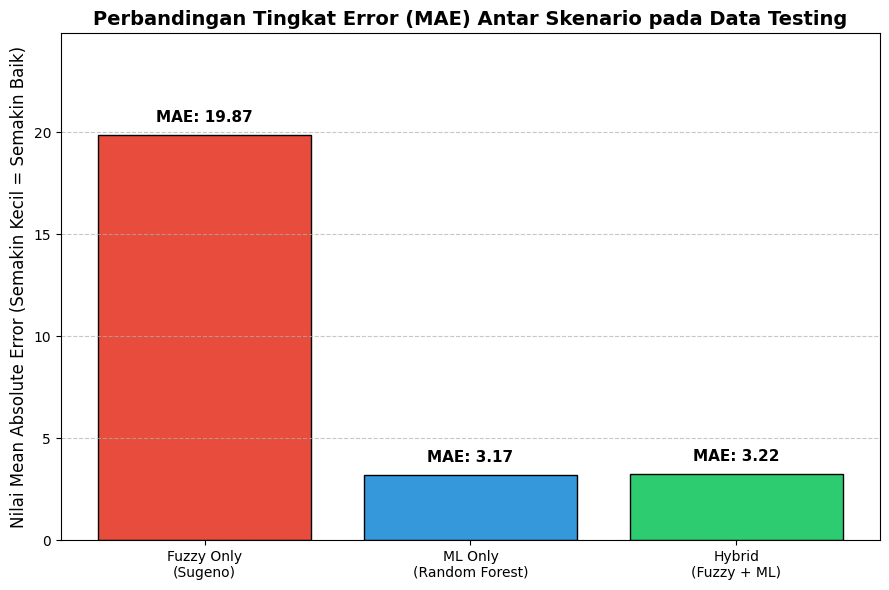

In [17]:
# VISUALISASI KESIMPULAN PERFORMA (Bar Chart MAE)
# -----------------------------------------------
import matplotlib.pyplot as plt

# Mendefinisikan nama skenario dan nilai MAE dari Tahap 6
skenario = ['Fuzzy Only\n(Sugeno)', 'ML Only\n(Random Forest)', 'Hybrid\n(Fuzzy + ML)']
mae_scores = [mae_fuzzy, mae_ml, mae_hybrid]

# Membuat figure
plt.figure(figsize=(9, 6))
bars = plt.bar(skenario, mae_scores, color=['#e74c3c', '#3498db', '#2ecc71'], edgecolor='black')

# Menambahkan anotasi/label angka tepat di atas masing-masing bar
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5, f'MAE: {yval:.2f}',
             ha='center', va='bottom', fontweight='bold', fontsize=11)

# Mempercantik tampilan
plt.title('Perbandingan Tingkat Error (MAE) Antar Skenario pada Data Testing', fontsize=14, fontweight='bold')
plt.ylabel('Nilai Mean Absolute Error (Semakin Kecil = Semakin Baik)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, max(mae_scores) + 5) # Memberi ruang kosong di atas bar untuk label angka

plt.tight_layout()
plt.show()

In [18]:
import joblib
# Menyimpan model Random Forest Hybrid ke dalam file
joblib.dump(rf_hybrid, 'model_hybrid.pkl')

['model_hybrid.pkl']